In [ ]:
from GradientGang.Pipeline.DataLoader.DataLoader import DataModule

params = {
    'data_dir': "../dataset/PirateProcessed/",
    'train_file_name': "pirate_pain_train.csv",
    'train_file_name_labels': "pirate_pain_train_labels.csv",
    'test_file_name': "pirate_pain_test.csv",
    'batch_size': 32,
    'num_workers': 0,
    'val_split': 0.1,
    'shuffle': True,
}

dataLoader = DataModule(params=params)
dataLoader.setup(stage='fit')

trainLoader = dataLoader.train_dataloader()
valLoader = dataLoader.val_dataloader()

dataLoader.setup(stage='test')
testLoader = dataLoader.test_dataloader()

In [ ]:
for batch in trainLoader:
    (time_series, global_features), labels = batch
    print("Train Batch - Time Series Shape:", time_series.shape)
    print("Train Batch - Global Features Shape:", global_features.shape)
    print("Train Batch - Labels Shape:", labels.shape)
    break

Train Batch - Time Series Shape: torch.Size([32, 34, 160])
Train Batch - Global Features Shape: torch.Size([32, 1])
Train Batch - Labels Shape: torch.Size([32])


In [ ]:
from GradientGang.Pipeline.Architectures.LightningAutoencoder import LightningAutoencoder
from torchsummary import summary

In [ ]:
# Reload the modules to get the latest changes
import importlib
import GradientGang.Pipeline.Architectures.LightningAutoencoder
import GradientGang.Pipeline.Architectures.Decoder
importlib.reload(GradientGang.Pipeline.Architectures.Decoder)
importlib.reload(GradientGang.Pipeline.Architectures.LightningAutoencoder)
from GradientGang.Pipeline.Architectures.LightningAutoencoder import LightningAutoencoder

In [ ]:
# CORRECTED ARCHITECTURE - Fixed decoder output shape
architectureParams_fixed = {
    "LearningRate": 0.001,
    "Patience": 5,
    "RegularizationWeight": 0.1,
    "EncoderParams": {
        "activation_function": "GELU",
        "layer_type": [
            {
                "name": "GRU",
                "params": {
                    "input_size": 34,
                    "hidden_size": 128,
                    "num_layers": 1,
                    "bias": True,
                    "batch_first": True,
                    "dropout": 0.0,
                    "bidirectional": True  # When True, output is hidden_size * 2 = 256
                }
            },
            {
                "name": "Linear",
                "params": {
                    "in_features": 256,  # 128 * 2 because bidirectional=True
                    "out_features": 128,
                    "bias": True,
                }
            }
        ]
    },
    "DecoderParams": {
        "activation_function": "GELU",
        "layer_type": [
            {
                "name": "Linear",
                "params": {
                    "in_features": 128,
                    "out_features": 128,  # GRU hidden_size
                    "bias": True,
                }
            },
            {
                "name": "GRU",
                "params": {
                    "input_size": 128,  # This receives the Linear output
                    "hidden_size": 128,
                    "num_layers": 1,
                    "bias": True,
                    "batch_first": True,
                    "dropout": 0.0,
                    "bidirectional": True  # When True, output is hidden_size * 2 = 256
                }
            },
            {
                "name": "Linear",
                "params": {
                    "in_features": 256,  # 128 * 2 because bidirectional=True
                    "out_features": 34,  # MUST MATCH INPUT FEATURES!
                    "bias": True,
                }
            }
        ]
    },
    "FeedForwardParams": {
        "activation_function": "ReLU",
        "layer_type": [
            {
                "name": "Linear",
                "params": {
                    "in_features": 129,  # 128 (encoder) + 1 (global)
                    "out_features": 64,
                    "bias": True,
                }
            },
            {
                "name": "Linear",
                "params": {
                    "in_features": 64,
                    "out_features": 10,
                    "bias": True,
                }
            }
        ]
    },
    "GlobalFFEncoderParams": {
        "activation_function": "LeakyReLU",
        "layer_type": [
            {
                "name": "Linear",
                "params": {
                    "in_features": 1,
                    "out_features": 1,
                    "bias": True,
                }
            },
        ]
    },
    "GlobalFFDecoderParams": {
        "activation_function": "LeakyReLU",
        "layer_type": [
            {
                "name": "Linear",
                "params": {
                    "in_features": 1,
                    "out_features": 1,
                    "bias": True,
                }
            },
        ]
    },
    "OutputDim": 3
}

# Create new autoencoder with fixed configuration
autoencoder_fixed = LightningAutoencoder(architectureParams_fixed)


In [ ]:
# Test the fixed autoencoder to verify shapes match
import torch
with torch.no_grad():
    test_batch = next(iter(trainLoader))
    (test_time_series, test_global_features), test_labels = test_batch
    print("✓ Input time series shape:", test_time_series.shape)
    print("✓ Input global features shape:", test_global_features.shape)
    
    predictions, (decoded, decoded_globalFeatures) = autoencoder_fixed((test_time_series, test_global_features))
    
    print("\n✓ Output predictions shape:", predictions.shape)
    print("✓ Decoded time series shape:", decoded.shape)
    print("✓ Decoded global features shape:", decoded_globalFeatures.shape)
    
    print("\n" + "="*50)
    print("SHAPE VERIFICATION:")
    print("="*50)
    print(f"Input  time series: {test_time_series.shape}")
    print(f"Output time series: {decoded.shape}")
    print(f"Match? {'✅ YES' if decoded.shape == test_time_series.shape else '❌ NO'}")
    
    print(f"\nInput  global features: {test_global_features.shape}")
    print(f"Output global features: {decoded_globalFeatures.shape}")
    print(f"Match? {'✅ YES' if decoded_globalFeatures.shape == test_global_features.shape else '❌ NO'}")

✓ Input time series shape: torch.Size([32, 34, 160])
✓ Input global features shape: torch.Size([32, 1])


RuntimeError: mat1 and mat2 shapes cannot be multiplied (5120x256 and 128x128)

In [ ]:
from pytorch_lightning import Trainer

trainer = Trainer(max_epochs=50, enable_progress_bar=True,)
trainer.fit(autoencoder_fixed, trainLoader, valLoader)


💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

  | Name             | Type              | Params | Mode 
---------------------------------------------------------------
0 | encoder          | Encoder           | 79.5 K | train
1 | decoder          | Decoder           | 119 K  | train
2 | globalff_encoder | FeedForward       | 2      | train
3 | globalff_decoder | FeedForward       | 2      | train
4 | feedforward      | FeedForward       | 9.0 K  | train
5 | val_f1           | MulticlassF1Score | 0      | train
---------------------------------------------------------------
208 K     Trainable params
0         Non-trainable params
208 K     Total params
0.834     Total estimated model params size (MB)
27        Modules i

Sanity Checking DataLoader 0: 100%|██████████| 2/2 [00:00<00:00, 11.94it/s]

c:\Users\teopa\Documents\ANN-Challenges\.venv\Lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:433: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.


c:\Users\teopa\Documents\ANN-Challenges\.venv\Lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:433: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.


Epoch 49: 100%|██████████| 60/60 [00:10<00:00,  5.86it/s, v_num=3, val_reconstruction_loss=0.439, val_F1=0.815]

`Trainer.fit` stopped: `max_epochs=50` reached.


Epoch 49: 100%|██████████| 60/60 [00:10<00:00,  5.85it/s, v_num=3, val_reconstruction_loss=0.439, val_F1=0.815]


In [ ]:
# Compute F1 score on val set using the FIXED autoencoder
from torchmetrics import F1Score
import torch

all_preds = []
all_labels = []
for batch in valLoader:
    x, labels = batch
    with torch.no_grad():
        preds = autoencoder_fixed(x)[0]  # Changed to autoencoder_fixed
    all_preds.extend(preds.argmax(dim=1).cpu().numpy())
    all_labels.extend(labels)

print(all_preds)
print(all_labels)

f1 = F1Score(task="multiclass", num_classes=3, average='macro')
f1 = f1(torch.tensor(all_preds), torch.tensor(all_labels))
print("Validation F1 Score:", f1)


[np.int64(0), np.int64(0), np.int64(2), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(1), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(2), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(2), np.int64(0), np.int64(1), np.int64(0), np.int64(2), np.int64(0), np.int64(1), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(2), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(2), np.int64(2), np.int64(0), np.int64(0), np.int64(0), np.int64(1), np.int64(0), np.int64(2), np.int64(2), np.int64(2), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(2), np.int64(0), np.int64(0), np.int64(1), np.int64(0), np.int64(1), np.int64(1), np.int64(1), np.int64(0)]
[tensor(0), tensor(0), tensor(2), tensor(0), tensor(2), tensor(0), tensor(0), tensor(0), tensor(1), tensor(0), tensor(0), tensor(0), tensor(1

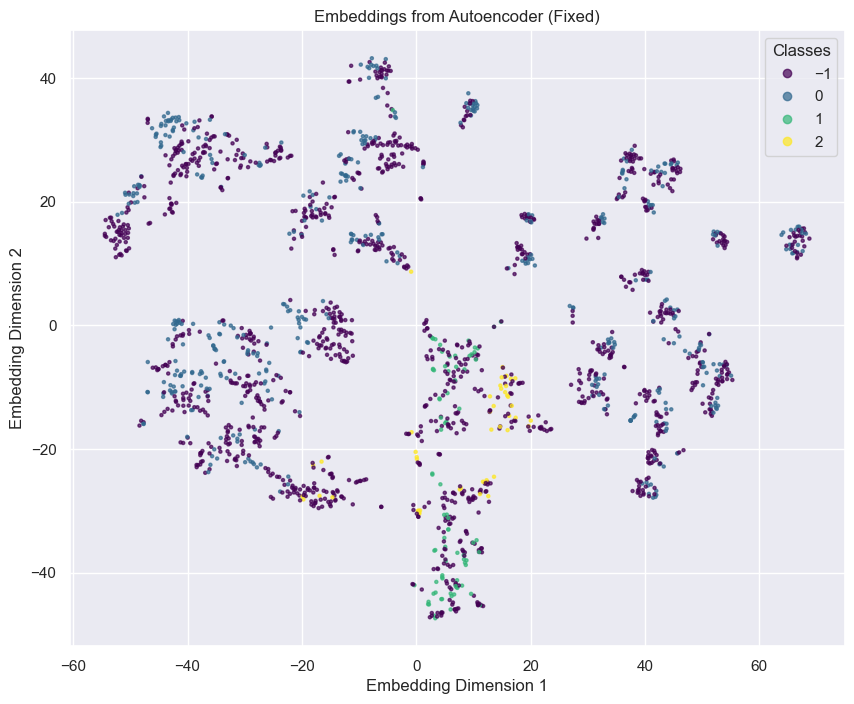

In [ ]:
# Plot embeddings using the FIXED autoencoder
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE
import torch
sns.set_theme()

embeddings = []
labels_list = []
for batch in trainLoader:
    (time_series, global_features), labels = batch
    with torch.no_grad():
        # Encoder expects the time-series tensor (batch, channels, seq_len)
        embedding = autoencoder_fixed.encoder(time_series)  # Changed to autoencoder_fixed
    embeddings.append(embedding.cpu())
    labels_list.append(labels)

embeddings = torch.cat(embeddings, dim=0).numpy()
labels_list = torch.cat(labels_list, dim=0).numpy()

tsne = TSNE(n_components=2, random_state=42)
embeddings_2d = tsne.fit_transform(embeddings)

plt.figure(figsize=(10, 8))
scatter = plt.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1], c=labels_list, alpha=0.7, cmap='viridis', s=5)
plt.legend(*scatter.legend_elements(), title="Classes")
plt.title('Embeddings from Autoencoder (Fixed)')
plt.xlabel('Embedding Dimension 1')
plt.ylabel('Embedding Dimension 2')
plt.show()
